# Low Dissolved Oxygen Analysis — Village-Level Adaptive Thresholds & Data Sufficiency

This notebook assesses whether we have enough data to determine:

1. **Within-village:** Which ponds within a village will be relatively worse (lower DO than the village's own baseline)?
2. **Between-village:** Which villages will be relatively worse (lower DO than their local-area norm)?

"Relatively worse" is defined against each village's own long-run average, adjusted for local weather effects using nearby-village DO as a spatial control.

**Approach:**
- **Step 1** — Merge water quality with location data; drop ponds with no location.
- **Step 2** — Build village-specific "low DO" thresholds using same-day nearby-village comparisons.
- **Step 3** — Assess data sufficiency: positive/negative sample counts across and within villages for ML modelling.

# Step 1 — Merge Water Quality with Location Data

Replicate the merge from `water_qual_by_no_location.ipynb` (cell 2), then **drop** all observations with no location. Focus on morning observations since DO is lowest in the morning — the operationally relevant window for detecting dangerously low DO.

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from scipy.spatial.distance import pdist, squareform

sns.set_theme(style="whitegrid", palette="muted")

# ── Load raw data ─────────────────────────────────────────────────────────────
wq  = pd.read_csv('data/water_quality.csv')
loc = pd.read_csv('data/Shared_ 2026 Github ARA Pond IDs Key.csv')

# ── Coerce location numeric fields ────────────────────────────────────────────
loc['latitude']  = pd.to_numeric(loc['latitude'],  errors='coerce')
loc['longitude'] = pd.to_numeric(loc['longitude'], errors='coerce')

# ── Identify no-location ponds ────────────────────────────────────────────────
loc['_has_coords']  = loc['latitude'].notna() & loc['longitude'].notna()
loc['_has_village']  = loc['village'].notna() & loc['village'].astype(str).str.strip().ne('')
loc['no_location']   = ~(loc['_has_coords'] | loc['_has_village'])

loc_slim = loc[['public_pond_id', 'region', 'village', 'latitude', 'longitude', 'no_location']].copy()

# ── Merge ─────────────────────────────────────────────────────────────────────
df = wq.merge(loc_slim, left_on='pond_id', right_on='public_pond_id', how='left')
df['no_location'] = df['no_location'].fillna(True)

# ── Drop no-location observations ────────────────────────────────────────────
df = df[~df['no_location']].copy()

# ── Filter to morning, parse date, coerce DO ─────────────────────────────────
df = df[df['Type'].str.lower() == 'morning'].copy()
df['date'] = pd.to_datetime(df['Date of data collection'], format='%m/%d/%Y')
df['DO (mg/L)'] = pd.to_numeric(df['DO (mg/L)'], errors='coerce')
df = df.dropna(subset=['DO (mg/L)'])
df = df.drop_duplicates(subset=['date', 'pond_id'])

# Use region_y from the location table (more reliable)
if 'region_y' in df.columns:
    df['region'] = df['region_y']

print(f"Morning observations with location & valid DO: {len(df):,}")
print(f"Unique ponds : {df['pond_id'].nunique()}")
print(f"Unique villages: {df['village'].nunique()}")
print(f"Date range   : {df['date'].min().date()} → {df['date'].max().date()}")
print(f"\nDO summary:")
print(df['DO (mg/L)'].describe().round(2))
print(f"\nObservations per village:")
print(df.groupby('village').agg(
    n_obs=('pond_id','count'), n_ponds=('pond_id','nunique')
).sort_values('n_obs', ascending=False).to_string())

Morning observations with location & valid DO: 5,130
Unique ponds : 251
Unique villages: 22
Date range   : 2021-07-06 → 2026-01-27

DO summary:
count    5130.00
mean        3.50
std         0.85
min         0.00
25%         3.20
50%         3.50
75%         3.90
max        14.60
Name: DO (mg/L), dtype: float64

Observations per village:
                 n_obs  n_ponds
village                        
Sreeparru          808       28
Komarika           667       15
Jalipudi           508       37
Maanuru            417       16
Ponangi            397       18
Indukurpeta        356       11
Somarajupalli      315       11
Durgapuram         300       17
Koniki             188       13
Jayampuram         166       13
Veeramma Kunta     163       11
Pathamupparu       159        8
Nidimusili         124        3
Madepalli          116        5
Gudivakalanka       95       10
Aamuluru            93        5
Mudivarthipalem     88        2
Gogunta             84       18
Mupparu             3

# Step 2 — Village-Specific "Low DO" Thresholds

**Logic:** Weather drives daily DO for an entire area. On any given day, nearby villages should have correlated DO. If a village consistently reads higher (or lower) than its neighbours, that systematic offset reflects pond-specific factors (water depth, aeration, stocking density, etc).

**Method:**
1. Compute village centroids from GPS coordinates.
2. Build a haversine distance matrix between village centroids. Define "nearby" as villages within 30 km (captures within-region neighbours; the two regions — Eluru & Nellore — are ~250 km apart).
3. For each village on each date, compute the village's mean DO and the mean DO of all nearby-village ponds on the same day.
4. Village bias = median of (village_DO − neighbour_DO) across all shared dates.
5. **Adaptive threshold** = `3.0 + bias`: a village that consistently runs 1 mg/L above neighbours gets a threshold of 4.0; one that runs 0.5 below gets 2.5.

This is clamped to [1.5, 5.0] to prevent extreme thresholds.

## 2a — Village Centroids & Distance Matrix

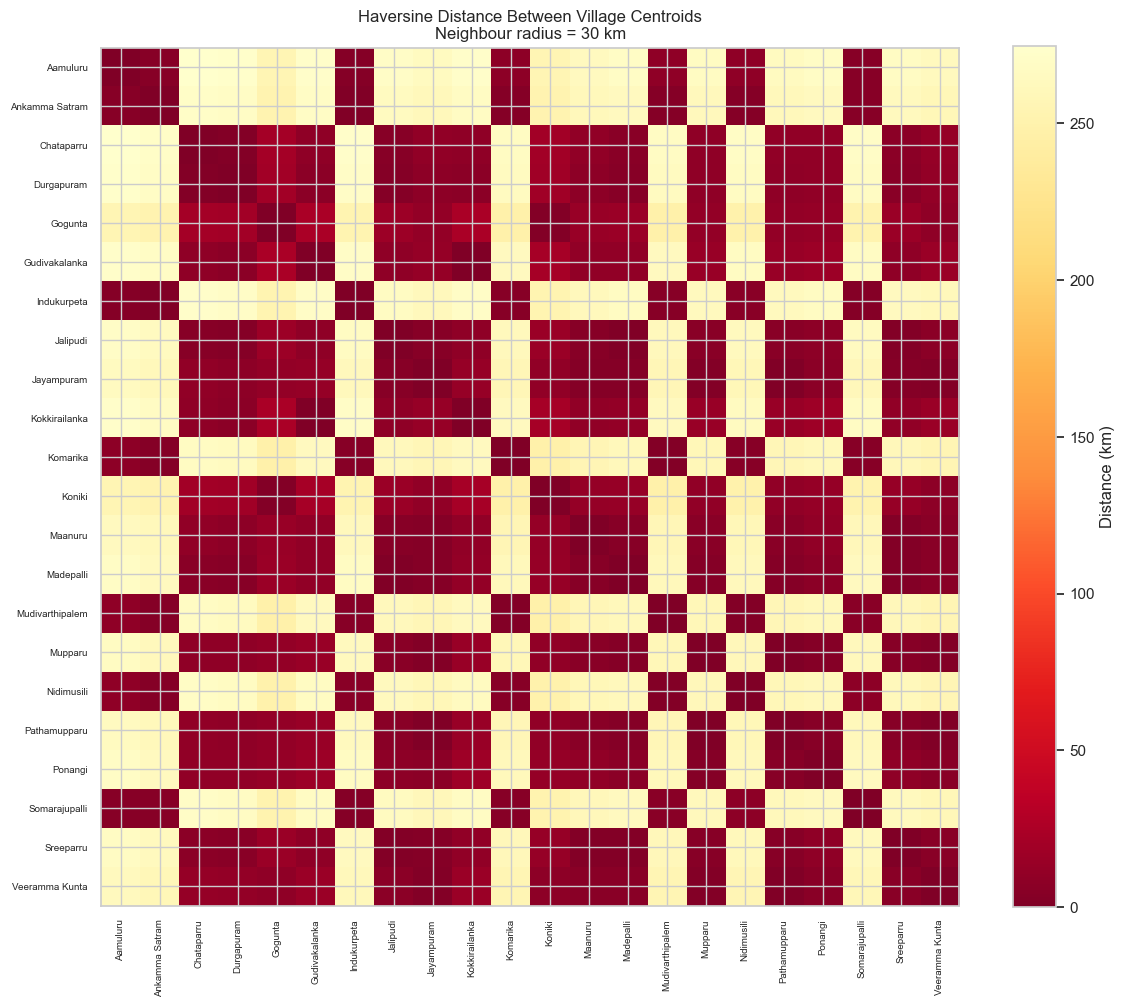

Aamuluru             [Nellore] → 6 neighbours: Indukurpeta (3.5km), Somarajupalli (4.8km), Ankamma Satram (5.1km), Komarika (7.8km), Mudivarthipalem (8.6km), Nidimusili (9.1km)
Ankamma Satram       [Nellore] → 6 neighbours: Indukurpeta (1.7km), Mudivarthipalem (3.6km), Komarika (3.6km), Nidimusili (4.1km), Somarajupalli (4.5km), Aamuluru (5.1km)
Chataparru           [Eluru] → 14 neighbours: Durgapuram (2.5km), Jalipudi (4.9km), Madepalli (6.1km), Sreeparru (7.2km), Gudivakalanka (8.7km), Kokkirailanka (9.4km), Mupparu (9.5km), Maanuru (9.8km), Jayampuram (9.8km), Pathamupparu (9.9km), Ponangi (10.1km), Veeramma Kunta (11.9km), Koniki (19.6km), Gogunta (21.0km)
Durgapuram           [Eluru] → 14 neighbours: Chataparru (2.5km), Jalipudi (3.5km), Madepalli (5.1km), Sreeparru (5.4km), Gudivakalanka (6.7km), Kokkirailanka (7.4km), Maanuru (7.8km), Jayampuram (8.6km), Mupparu (8.9km), Pathamupparu (9.1km), Ponangi (10.7km), Veeramma Kunta (11.0km), Koniki (18.5km), Gogunta (20.2km)
Gogunta   

In [2]:
# ── Village centroids (mean lat/lon of ponds with coordinates) ─────────────────
village_geo = (
    loc[loc['_has_coords']]
    .groupby('village')
    .agg(lat=('latitude','mean'), lon=('longitude','mean'),
         n_ponds_loc=('public_pond_id','count'),
         region=('region','first'))
    .reset_index()
)

# ── Haversine distance matrix (km) ───────────────────────────────────────────
def haversine_km(lat1, lon1, lat2, lon2):
    """Vectorised haversine between two points in degrees → km."""
    R = 6371.0
    lat1, lon1, lat2, lon2 = map(np.radians, [lat1, lon1, lat2, lon2])
    dlat = lat2 - lat1
    dlon = lon2 - lon1
    a = np.sin(dlat / 2)**2 + np.cos(lat1) * np.cos(lat2) * np.sin(dlon / 2)**2
    return R * 2 * np.arcsin(np.sqrt(a))

n_v = len(village_geo)
dist_matrix = np.zeros((n_v, n_v))
for i in range(n_v):
    for j in range(i + 1, n_v):
        d = haversine_km(village_geo.iloc[i]['lat'], village_geo.iloc[i]['lon'],
                         village_geo.iloc[j]['lat'], village_geo.iloc[j]['lon'])
        dist_matrix[i, j] = d
        dist_matrix[j, i] = d

NEIGHBOUR_RADIUS_KM = 30
neighbour_mask = (dist_matrix > 0) & (dist_matrix <= NEIGHBOUR_RADIUS_KM)

# ── Show distance matrix as a heatmap ─────────────────────────────────────────
fig, ax = plt.subplots(figsize=(12, 10))
im = ax.imshow(dist_matrix, cmap='YlOrRd_r')
ax.set_xticks(range(n_v))
ax.set_yticks(range(n_v))
ax.set_xticklabels(village_geo['village'], rotation=90, fontsize=7)
ax.set_yticklabels(village_geo['village'], fontsize=7)
plt.colorbar(im, ax=ax, label='Distance (km)')
ax.set_title(f'Haversine Distance Between Village Centroids\n'
             f'Neighbour radius = {NEIGHBOUR_RADIUS_KM} km')
plt.tight_layout()
plt.show()

# Neighbour table
villages = village_geo['village'].values
for i, v in enumerate(villages):
    nbrs = villages[neighbour_mask[i]]
    dists = dist_matrix[i][neighbour_mask[i]]
    nbr_str = ', '.join(f'{n} ({d:.1f}km)' for n, d in sorted(zip(nbrs, dists), key=lambda x: x[1]))
    print(f"{v:20s} [{village_geo.iloc[i]['region']}] → {len(nbrs)} neighbours: {nbr_str}")

## 2b — Village-Day Mean DO & Neighbour Comparison

For each (village, date) pair, compute:
- **village_mean_do**: mean DO across all ponds in that village on that date.
- **neighbour_mean_do**: mean DO across all ponds in neighbouring villages on the same date.
- **delta**: village_mean_do − neighbour_mean_do (positive = village is higher than neighbours).

In [3]:
# ── Village-day averages ───────────────────────────────────────────────────────
village_day = (
    df.groupby(['village', 'date'])
    .agg(village_mean_do=('DO (mg/L)', 'mean'),
         village_n_ponds=('pond_id', 'nunique'))
    .reset_index()
)

# ── Map village name → index in village_geo ───────────────────────────────────
v_to_idx = {v: i for i, v in enumerate(village_geo['village'].values)}

# ── For each village-day, compute neighbour mean DO ───────────────────────────
# Pre-compute a date→{village: mean_do} lookup for speed
date_village_do = village_day.set_index(['date', 'village'])['village_mean_do'].to_dict()

rows = []
for _, row in village_day.iterrows():
    v = row['village']
    d = row['date']
    v_idx = v_to_idx.get(v)
    if v_idx is None:
        continue
    # Get neighbour villages
    nbr_indices = np.where(neighbour_mask[v_idx])[0]
    nbr_dos = []
    for ni in nbr_indices:
        nbr_village = villages[ni]
        nbr_do = date_village_do.get((d, nbr_village))
        if nbr_do is not None:
            nbr_dos.append(nbr_do)
    rows.append({
        'village': v,
        'date': d,
        'village_mean_do': row['village_mean_do'],
        'village_n_ponds': row['village_n_ponds'],
        'neighbour_mean_do': np.mean(nbr_dos) if nbr_dos else np.nan,
        'n_neighbour_villages': len(nbr_dos),
    })

vd = pd.DataFrame(rows)
vd['delta'] = vd['village_mean_do'] - vd['neighbour_mean_do']
vd = vd.dropna(subset=['delta'])

print(f"Village-day rows with neighbour data: {len(vd):,}")
print(f"Villages represented: {vd['village'].nunique()}")
print(f"\nDelta (village − neighbour) summary:")
print(vd['delta'].describe().round(2))

Village-day rows with neighbour data: 1,389
Villages represented: 22

Delta (village − neighbour) summary:
count    1389.00
mean        0.00
std         0.82
min        -5.10
25%        -0.35
50%         0.00
75%         0.37
max         5.10
Name: delta, dtype: float64


## 2c — Compute Village Bias & Adaptive Thresholds

**Village bias** = median delta across all dates where the village and at least one neighbour were both measured.

- Positive bias → village consistently runs higher than neighbours → **higher** low-DO threshold.
- Negative bias → village consistently runs lower → **lower** threshold.

**Adaptive threshold = clamp(3.0 + bias, 1.5, 5.0)**

Village adaptive thresholds (sorted by threshold):

        village  region  n_ponds_loc  n_comparison_days  median_delta  mean_delta  threshold
 Ankamma Satram Nellore            1                 18         -0.30       -0.51       2.70
  Kokkirailanka   Eluru            1                  4         -0.26       -0.13       2.74
       Aamuluru Nellore            5                  7         -0.20       -0.13       2.80
        Mupparu   Eluru            2                 26         -0.13       -0.01       2.88
        Gogunta   Eluru           18                 26         -0.10       -0.01       2.90
      Madepalli   Eluru            5                 70         -0.10       -0.13       2.90
      Sreeparru   Eluru           28                242         -0.10       -0.18       2.90
     Durgapuram   Eluru           17                106         -0.06       -0.13       2.94
     Nidimusili Nellore            3                 43         -0.05       -0.12       2.95
   Pathamupparu   

/var/folders/1c/f0j4ygyd0jb136rvzr4n3sp00000gp/T/ipykernel_79850/2208440541.py:56: UserWarning: Glyph 8733 (\N{PROPORTIONAL TO}) missing from font(s) Arial.
  plt.tight_layout()
/Users/dlau/repos/fish-welfare/.venv/lib/python3.14/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 8733 (\N{PROPORTIONAL TO}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


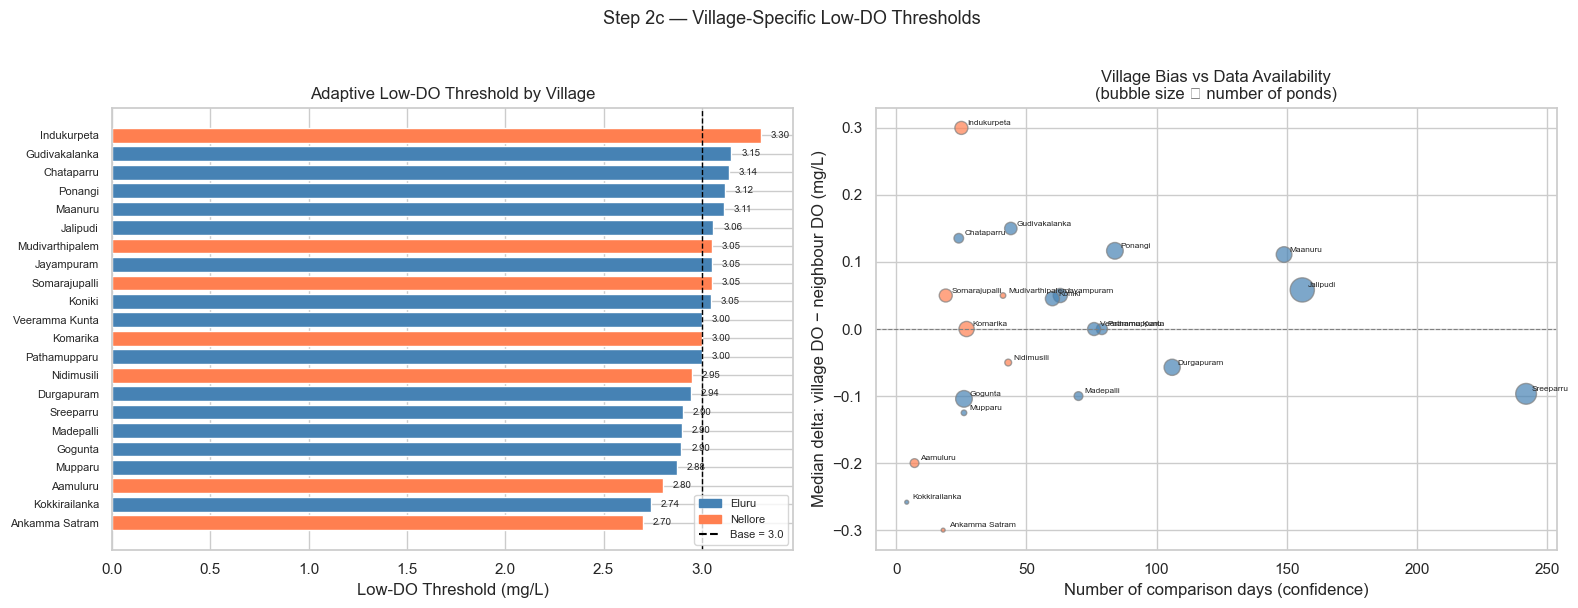

In [4]:
BASE_THRESHOLD = 3.0
THRESHOLD_LB, THRESHOLD_UB = 1.5, 5.0

village_bias = (
    vd.groupby('village')
    .agg(median_delta=('delta', 'median'),
         mean_delta=('delta', 'mean'),
         n_comparison_days=('delta', 'count'))
    .reset_index()
)
village_bias['threshold'] = (BASE_THRESHOLD + village_bias['median_delta']).clip(THRESHOLD_LB, THRESHOLD_UB)

# Merge region info
village_bias = village_bias.merge(village_geo[['village', 'region', 'n_ponds_loc']], on='village', how='left')

print("Village adaptive thresholds (sorted by threshold):\n")
display_cols = ['village', 'region', 'n_ponds_loc', 'n_comparison_days',
                'median_delta', 'mean_delta', 'threshold']
print(village_bias[display_cols].sort_values('threshold').to_string(index=False, float_format='%.2f'))

# ── Visualisation ─────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Bar chart of thresholds
ax = axes[0]
vb_sorted = village_bias.sort_values('threshold')
colors = ['coral' if r == 'Nellore' else 'steelblue' for r in vb_sorted['region']]
ax.barh(vb_sorted['village'], vb_sorted['threshold'], color=colors)
ax.axvline(BASE_THRESHOLD, color='black', linestyle='--', linewidth=1, label=f'Base = {BASE_THRESHOLD}')
ax.set_xlabel('Low-DO Threshold (mg/L)')
ax.set_title('Adaptive Low-DO Threshold by Village')
ax.legend(fontsize=8)
ax.tick_params(axis='y', labelsize=8)
for i, (_, r) in enumerate(vb_sorted.iterrows()):
    ax.text(r['threshold'] + 0.05, i, f"{r['threshold']:.2f}", va='center', fontsize=7)
nellore_patch = mpatches.Patch(color='coral', label='Nellore')
eluru_patch   = mpatches.Patch(color='steelblue', label='Eluru')
ax.legend(handles=[eluru_patch, nellore_patch,
                   plt.Line2D([0],[0], color='black', linestyle='--', label=f'Base = {BASE_THRESHOLD}')],
          fontsize=8)

# Scatter: bias vs number of comparison days (confidence indicator)
ax = axes[1]
c = ['coral' if r == 'Nellore' else 'steelblue' for r in village_bias['region']]
ax.scatter(village_bias['n_comparison_days'], village_bias['median_delta'],
           c=c, s=village_bias['n_ponds_loc'] * 8, alpha=0.7, edgecolors='grey')
ax.axhline(0, color='grey', linestyle='--', linewidth=0.8)
for _, r in village_bias.iterrows():
    ax.annotate(r['village'], (r['n_comparison_days'], r['median_delta']),
                fontsize=6, xytext=(4, 2), textcoords='offset points')
ax.set_xlabel('Number of comparison days (confidence)')
ax.set_ylabel('Median delta: village DO - neighbour DO (mg/L)')
ax.set_title('Village Bias vs Data Availability\n(bubble size ~ number of ponds)')

plt.suptitle('Step 2c — Village-Specific Low-DO Thresholds', fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

## 2d — Visualise Daily Village-vs-Neighbour DO

For each village, show the time series of village mean DO vs neighbour mean DO. This makes the bias visually apparent — villages that consistently sit above (or below) their neighbours.

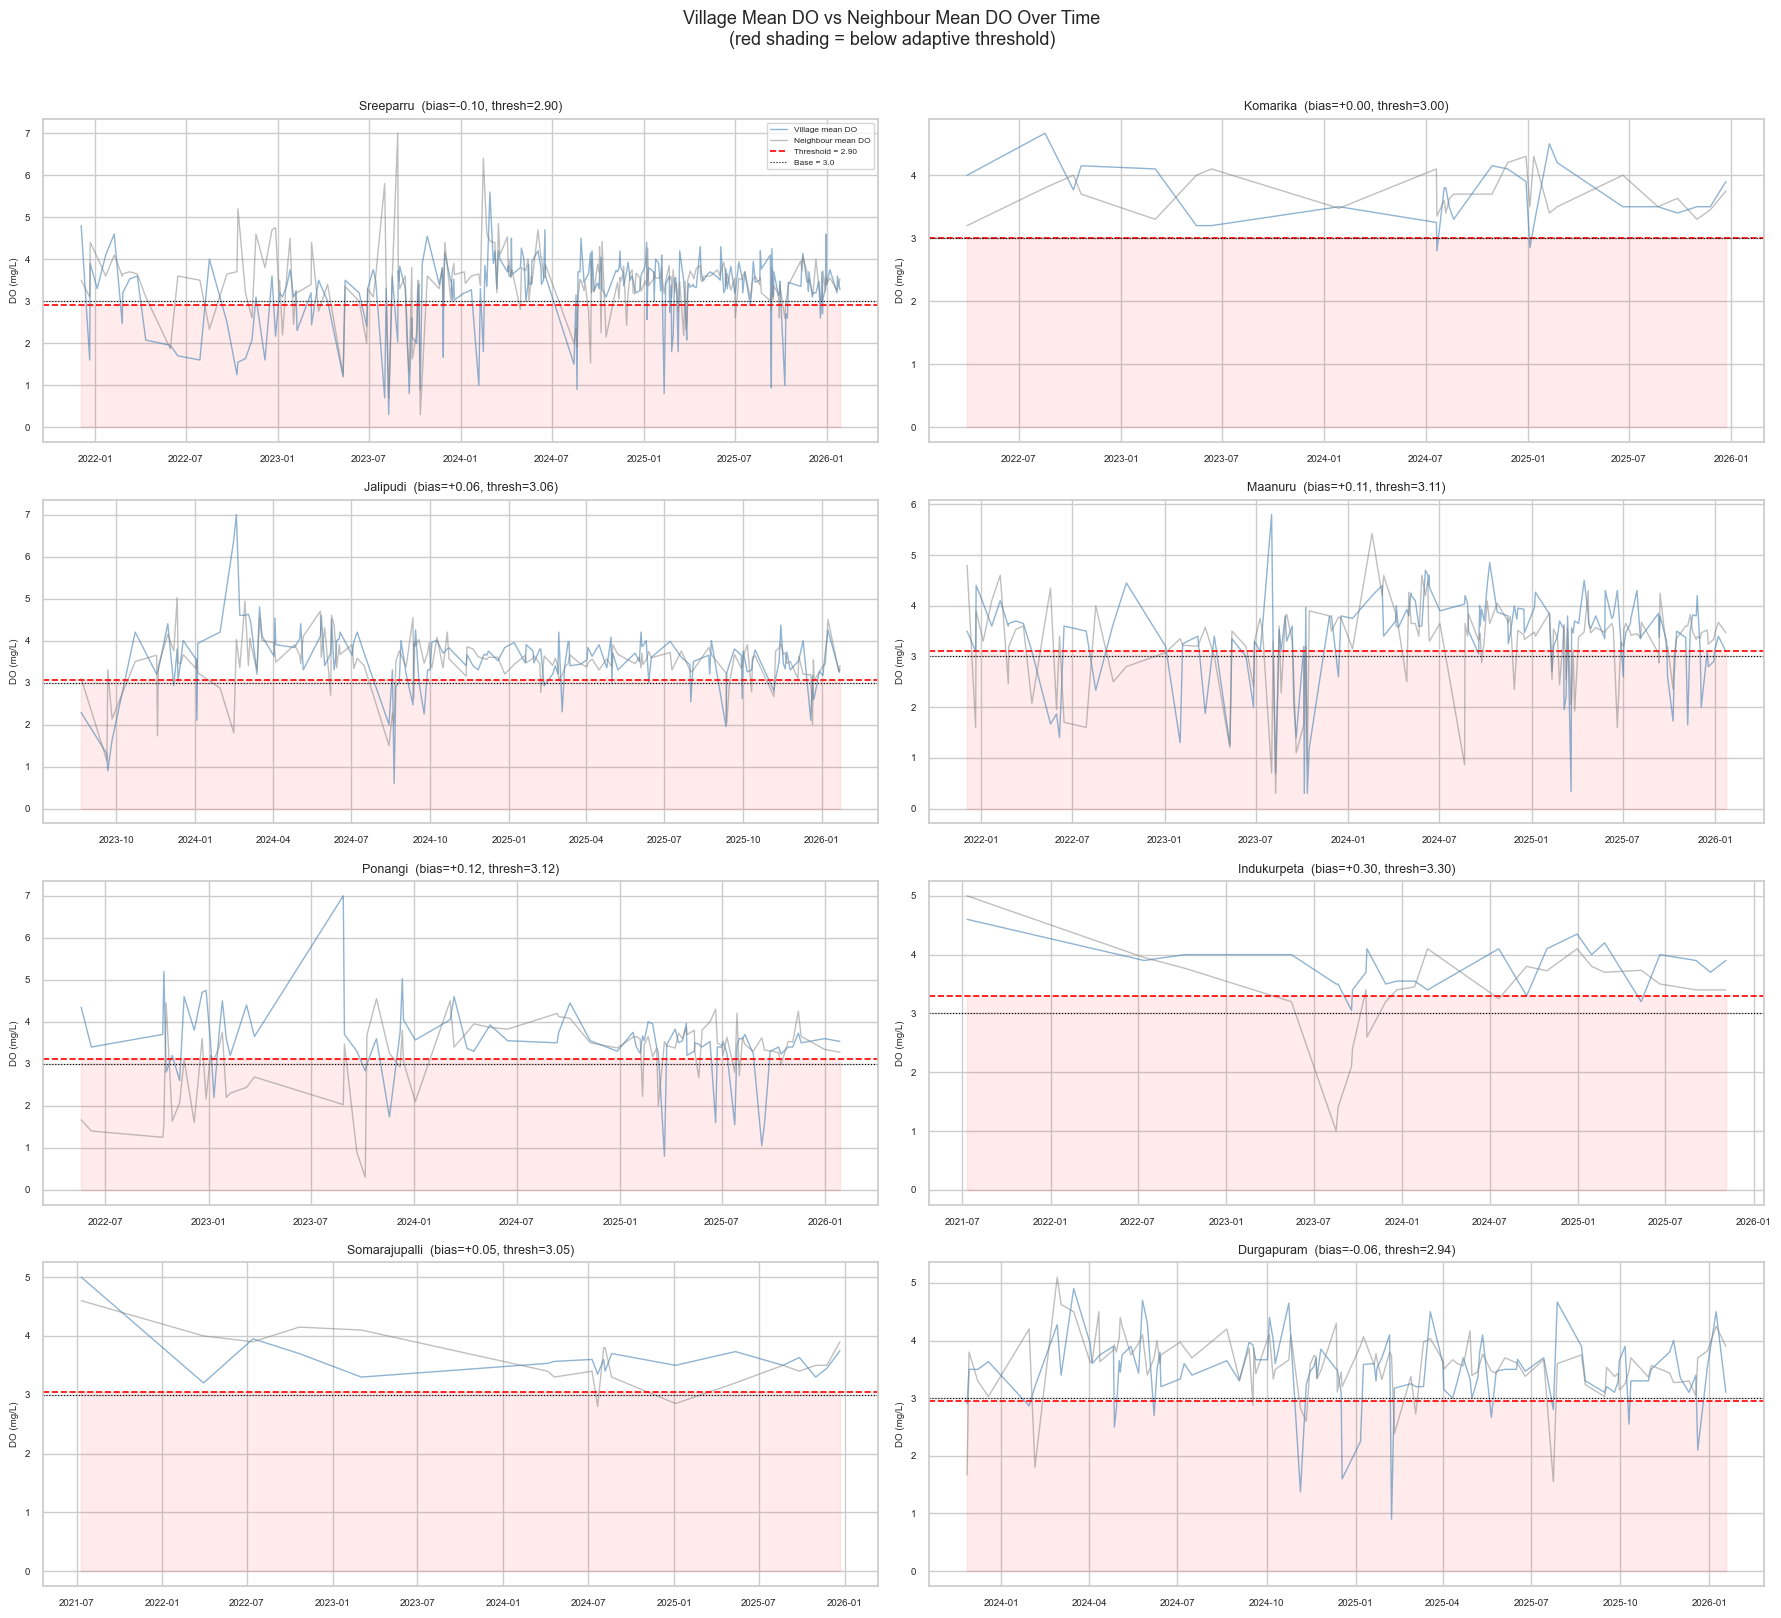

In [5]:
# Show top 8 villages by observation count
top_villages = (df.groupby('village')['pond_id'].count()
                .nlargest(8).index.tolist())

fig, axes = plt.subplots(4, 2, figsize=(18, 16))
axes = axes.flatten()

for i, v in enumerate(top_villages):
    ax = axes[i]
    sub = vd[vd['village'] == v].sort_values('date')
    thresh = village_bias.loc[village_bias['village'] == v, 'threshold'].values[0]
    bias_val = village_bias.loc[village_bias['village'] == v, 'median_delta'].values[0]

    ax.plot(sub['date'], sub['village_mean_do'], color='steelblue', alpha=0.6,
            linewidth=1, label='Village mean DO')
    ax.plot(sub['date'], sub['neighbour_mean_do'], color='grey', alpha=0.5,
            linewidth=1, label='Neighbour mean DO')
    ax.axhline(thresh, color='red', linestyle='--', linewidth=1.2,
               label=f'Threshold = {thresh:.2f}')
    ax.axhline(BASE_THRESHOLD, color='black', linestyle=':', linewidth=0.8,
               label=f'Base = {BASE_THRESHOLD}')
    ax.fill_between(sub['date'], 0, thresh, alpha=0.08, color='red')
    ax.set_title(f'{v}  (bias={bias_val:+.2f}, thresh={thresh:.2f})', fontsize=9)
    ax.set_ylabel('DO (mg/L)', fontsize=7)
    ax.tick_params(labelsize=7)
    if i == 0:
        ax.legend(fontsize=6, loc='upper right')

plt.suptitle('Village Mean DO vs Neighbour Mean DO Over Time\n'
             '(red shading = below adaptive threshold)', fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

# Step 3 — Data Sufficiency for ML Modelling

We now label every pond-day observation as **low DO** (1) or **normal** (0) using the village-specific adaptive thresholds, then assess whether the data supports:

1. **Between-village classification**: predicting which villages will be relatively worse.
2. **Within-village classification**: predicting which ponds within a village will be relatively worse.

Key metrics: positive rate, class balance per village, sample size per pond, and number of ponds per village with enough positive/negative examples.

## 3a — Label Observations & Overall Positive Rate

In [6]:
# ── Map adaptive threshold onto every observation ─────────────────────────────
threshold_map = village_bias.set_index('village')['threshold'].to_dict()
df['low_do_threshold'] = df['village'].map(threshold_map)

# Fall back to base threshold for villages not in the bias table
df['low_do_threshold'] = df['low_do_threshold'].fillna(BASE_THRESHOLD)

df['low_do'] = (df['DO (mg/L)'] <= df['low_do_threshold']).astype(int)

n_pos = df['low_do'].sum()
n_neg = len(df) - n_pos
print(f"Total observations : {len(df):,}")
print(f"Low-DO (positive)  : {n_pos:,}  ({n_pos/len(df)*100:.1f}%)")
print(f"Normal (negative)  : {n_neg:,}  ({n_neg/len(df)*100:.1f}%)")
print(f"\nFor reference with a flat 3.0 threshold:")
flat_pos = (df['DO (mg/L)'] <= 3.0).sum()
print(f"Low-DO (flat ≤3.0) : {flat_pos:,}  ({flat_pos/len(df)*100:.1f}%)")

Total observations : 5,130
Low-DO (positive)  : 697  (13.6%)
Normal (negative)  : 4,433  (86.4%)

For reference with a flat 3.0 threshold:
Low-DO (flat ≤3.0) : 710  (13.8%)


## 3b — Between-Village: Positive Rate by Village

If we want an ML model to predict **which villages will be relatively worse**, we need enough villages in both the "frequently low-DO" and "rarely low-DO" classes, each with enough observations to form robust train/test splits.

Village-level low-DO summary (adaptive thresholds):

        village  region  n_ponds  n_obs  n_positive  n_negative  positive_rate  threshold  mean_do
        Maanuru   Eluru       16    417         113         304           0.27       3.11     3.31
 Ankamma Satram Nellore        1     18           4          14           0.22       2.70     3.19
      Sreeparru   Eluru       28    808         169         639           0.21       2.90     3.24
    Indukurpeta Nellore       11    356          73         283           0.21       3.30     3.67
        Ponangi   Eluru       18    397          79         318           0.20       3.12     3.49
      Madepalli   Eluru        5    116          19          97           0.16       2.90     3.23
   Pathamupparu   Eluru        8    159          23         136           0.14       3.00     3.26
       Jalipudi   Eluru       37    508          73         435           0.14       3.06     3.53
     Durgapuram   Eluru       17    300          36     

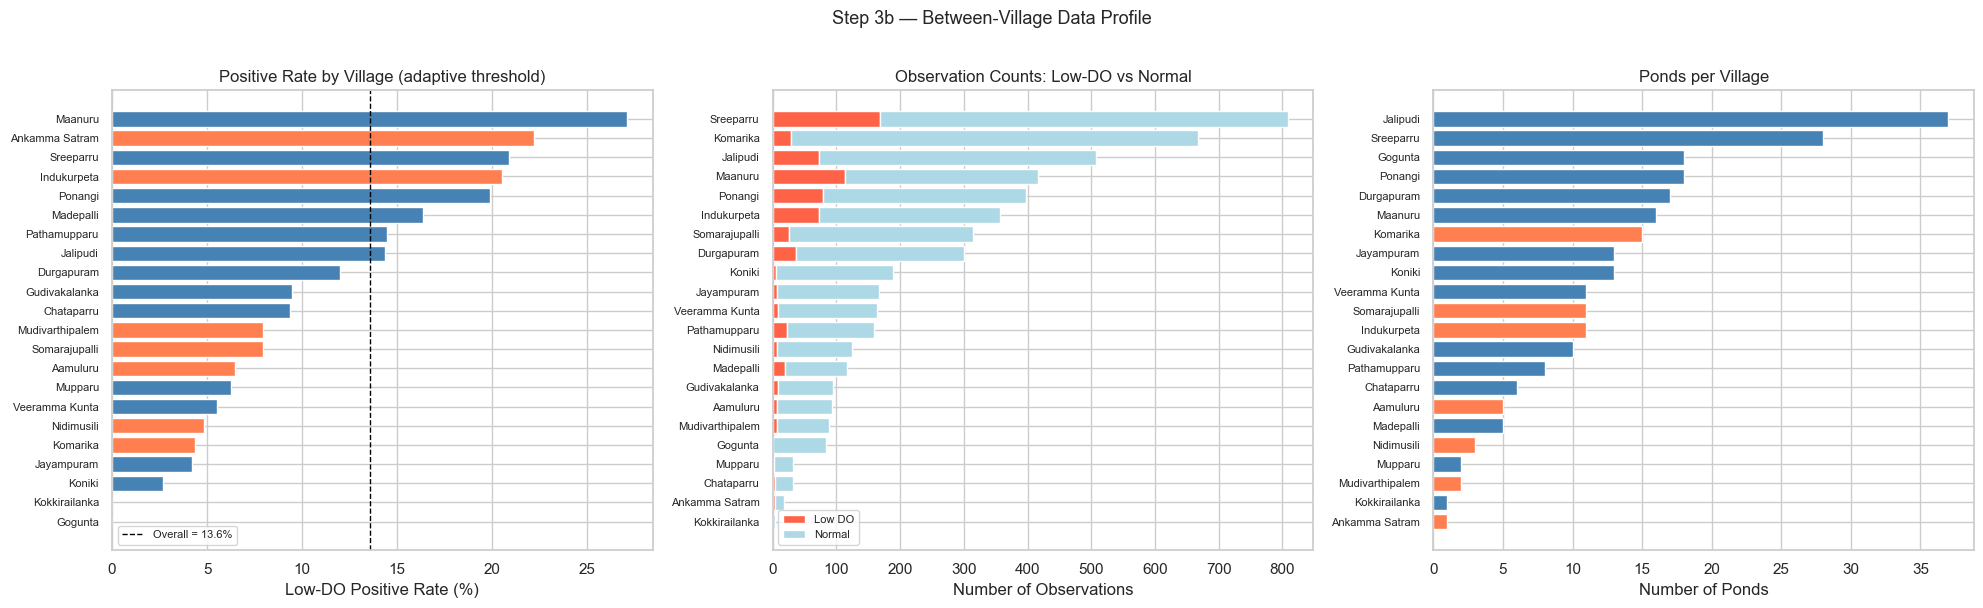


Villages with ≥30 observations: 20 / 22
  with positive rate >20%: 3
  with positive rate 5–20%: 12
  with positive rate <5%: 5

Median obs per village: 164
Median positive count per village: 14


In [7]:
# ── Village-level summary ──────────────────────────────────────────────────────
village_summary = (
    df.groupby('village')
    .agg(
        n_obs=('low_do', 'count'),
        n_positive=('low_do', 'sum'),
        n_ponds=('pond_id', 'nunique'),
        mean_do=('DO (mg/L)', 'mean'),
        threshold=('low_do_threshold', 'first'),
        region=('region', 'first'),
    )
    .reset_index()
)
village_summary['positive_rate'] = village_summary['n_positive'] / village_summary['n_obs']
village_summary['n_negative'] = village_summary['n_obs'] - village_summary['n_positive']
village_summary = village_summary.sort_values('positive_rate', ascending=False)

print("Village-level low-DO summary (adaptive thresholds):\n")
print(village_summary[['village','region','n_ponds','n_obs','n_positive','n_negative',
                        'positive_rate','threshold','mean_do']]
      .to_string(index=False, float_format='%.2f'))

# ── Visualise ─────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(20, 6))

# Positive rate bar
ax = axes[0]
vs = village_summary.sort_values('positive_rate')
colors = ['coral' if r == 'Nellore' else 'steelblue' for r in vs['region']]
ax.barh(vs['village'], vs['positive_rate'] * 100, color=colors)
ax.axvline(df['low_do'].mean() * 100, color='black', linestyle='--', linewidth=1,
           label=f"Overall = {df['low_do'].mean()*100:.1f}%")
ax.set_xlabel('Low-DO Positive Rate (%)')
ax.set_title('Positive Rate by Village (adaptive threshold)')
ax.legend(fontsize=8)
ax.tick_params(axis='y', labelsize=8)

# Counts: positive vs negative stacked bar
ax = axes[1]
vs2 = village_summary.sort_values('n_obs')
ax.barh(vs2['village'], vs2['n_positive'], color='tomato', label='Low DO')
ax.barh(vs2['village'], vs2['n_negative'], left=vs2['n_positive'], color='lightblue', label='Normal')
ax.set_xlabel('Number of Observations')
ax.set_title('Observation Counts: Low-DO vs Normal')
ax.legend(fontsize=8)
ax.tick_params(axis='y', labelsize=8)

# Pond count per village
ax = axes[2]
vs3 = village_summary.sort_values('n_ponds')
colors3 = ['coral' if r == 'Nellore' else 'steelblue' for r in vs3['region']]
ax.barh(vs3['village'], vs3['n_ponds'], color=colors3)
ax.set_xlabel('Number of Ponds')
ax.set_title('Ponds per Village')
ax.tick_params(axis='y', labelsize=8)

plt.suptitle('Step 3b — Between-Village Data Profile', fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

# ── Summary stats for between-village modelling ──────────────────────────────
MIN_OBS_VILLAGE = 30
usable = village_summary[village_summary['n_obs'] >= MIN_OBS_VILLAGE]
print(f"\nVillages with ≥{MIN_OBS_VILLAGE} observations: {len(usable)} / {len(village_summary)}")
print(f"  with positive rate >20%: {(usable['positive_rate'] > 0.20).sum()}")
print(f"  with positive rate 5–20%: {((usable['positive_rate'] >= 0.05) & (usable['positive_rate'] <= 0.20)).sum()}")
print(f"  with positive rate <5%: {(usable['positive_rate'] < 0.05).sum()}")
print(f"\nMedian obs per village: {usable['n_obs'].median():.0f}")
print(f"Median positive count per village: {usable['n_positive'].median():.0f}")

## 3c — Within-Village: Pond-Level Low-DO Rates

For within-village prediction, we need multiple ponds per village, each with enough observations (both positive and negative). Below we compute pond-level positive rates and assess how many ponds per village meet minimum sample-size thresholds.

Within-village pond data (ponds with ≥10 obs considered 'usable'):

        village  total_ponds  usable_ponds  usable_ponds_with_pos  usable_ponds_with_neg  usable_ponds_both_classes  median_obs_per_pond  median_pos_per_pond  rate_range  rate_std
      Sreeparru           28            24                     21                     24                         21                35.00                 7.00        0.58      0.15
       Jalipudi           37            24                     18                     24                         18                14.50                 3.00        0.36      0.11
       Komarika           15            15                     12                     15                         12                50.00                 2.00        0.09      0.03
        Maanuru           16            13                     12                     13                         12                23.00                 7.00        0.57      0.16
         Koniki           13    

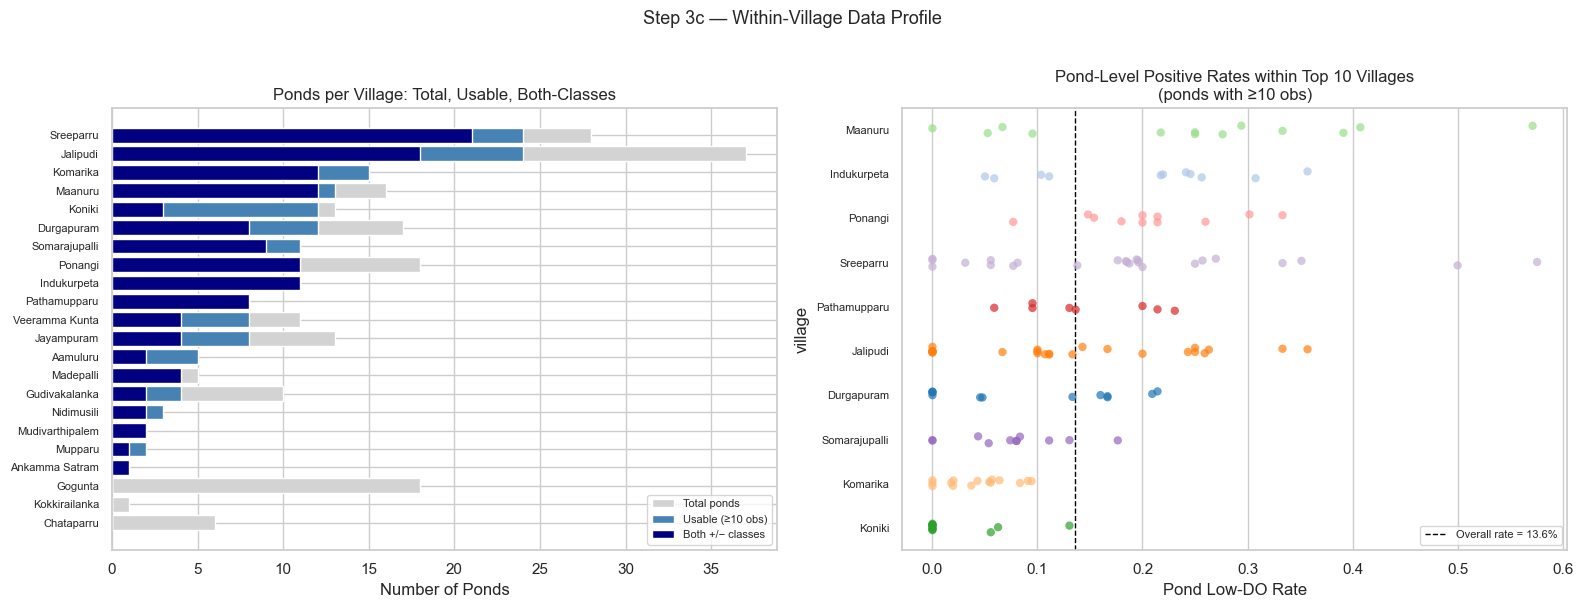

In [8]:
# ── Pond-level summary ─────────────────────────────────────────────────────────
pond_summary = (
    df.groupby(['village', 'pond_id'])
    .agg(
        n_obs=('low_do', 'count'),
        n_positive=('low_do', 'sum'),
        mean_do=('DO (mg/L)', 'mean'),
        threshold=('low_do_threshold', 'first'),
    )
    .reset_index()
)
pond_summary['positive_rate'] = pond_summary['n_positive'] / pond_summary['n_obs']
pond_summary['n_negative'] = pond_summary['n_obs'] - pond_summary['n_positive']

# ── Within-village variability: how spread out are pond positive rates? ───────
MIN_OBS_POND = 10  # pond needs ≥10 morning obs to be "usable"

within_village = []
for village, grp in pond_summary.groupby('village'):
    usable_ponds = grp[grp['n_obs'] >= MIN_OBS_POND]
    n_usable = len(usable_ponds)
    if n_usable >= 2:
        rate_range = usable_ponds['positive_rate'].max() - usable_ponds['positive_rate'].min()
        rate_std   = usable_ponds['positive_rate'].std()
    else:
        rate_range = np.nan
        rate_std   = np.nan
    within_village.append({
        'village': village,
        'total_ponds': len(grp),
        'usable_ponds': n_usable,
        'usable_ponds_with_pos': (usable_ponds['n_positive'] > 0).sum() if n_usable else 0,
        'usable_ponds_with_neg': (usable_ponds['n_negative'] > 0).sum() if n_usable else 0,
        'usable_ponds_both_classes': ((usable_ponds['n_positive'] > 0) & (usable_ponds['n_negative'] > 0)).sum() if n_usable else 0,
        'median_obs_per_pond': usable_ponds['n_obs'].median() if n_usable else np.nan,
        'median_pos_per_pond': usable_ponds['n_positive'].median() if n_usable else np.nan,
        'rate_range': rate_range,
        'rate_std': rate_std,
    })

wv = pd.DataFrame(within_village).sort_values('usable_ponds', ascending=False)

print(f"Within-village pond data (ponds with ≥{MIN_OBS_POND} obs considered 'usable'):\n")
print(wv.to_string(index=False, float_format='%.2f'))

# ── Visualisation ─────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Usable ponds per village
ax = axes[0]
wv_s = wv.sort_values('usable_ponds')
ax.barh(wv_s['village'], wv_s['total_ponds'], color='lightgrey', label='Total ponds')
ax.barh(wv_s['village'], wv_s['usable_ponds'], color='steelblue', label=f'Usable (≥{MIN_OBS_POND} obs)')
ax.barh(wv_s['village'], wv_s['usable_ponds_both_classes'], color='navy',
        label='Both +/− classes')
ax.set_xlabel('Number of Ponds')
ax.set_title('Ponds per Village: Total, Usable, Both-Classes')
ax.legend(fontsize=8)
ax.tick_params(axis='y', labelsize=8)

# Within-village positive-rate spread
ax = axes[1]
# Strip/swarm plot of pond positive rates by village (top villages)
top_v = wv.nlargest(10, 'usable_ponds')['village'].tolist()
plot_ponds = pond_summary[(pond_summary['village'].isin(top_v)) &
                          (pond_summary['n_obs'] >= MIN_OBS_POND)]
order = (plot_ponds.groupby('village')['positive_rate'].median()
         .sort_values(ascending=False).index.tolist())
sns.stripplot(data=plot_ponds, y='village', x='positive_rate', order=order,
              hue='village', palette='tab20', jitter=True, alpha=0.7, s=6, ax=ax,
              legend=False)
ax.axvline(df['low_do'].mean(), color='black', linestyle='--', linewidth=1,
           label=f"Overall rate = {df['low_do'].mean()*100:.1f}%")
ax.set_xlabel('Pond Low-DO Rate')
ax.set_title(f'Pond-Level Positive Rates within Top 10 Villages\n(ponds with ≥{MIN_OBS_POND} obs)')
ax.legend(fontsize=8)
ax.tick_params(axis='y', labelsize=8)

plt.suptitle('Step 3c — Within-Village Data Profile', fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

## 3d — Heatmap: Pond × Village Low-DO Rate Matrix

A visual summary of where positive samples concentrate. Each row is a village, each column is a pond (sorted by positive rate within village). Colour = low-DO rate.

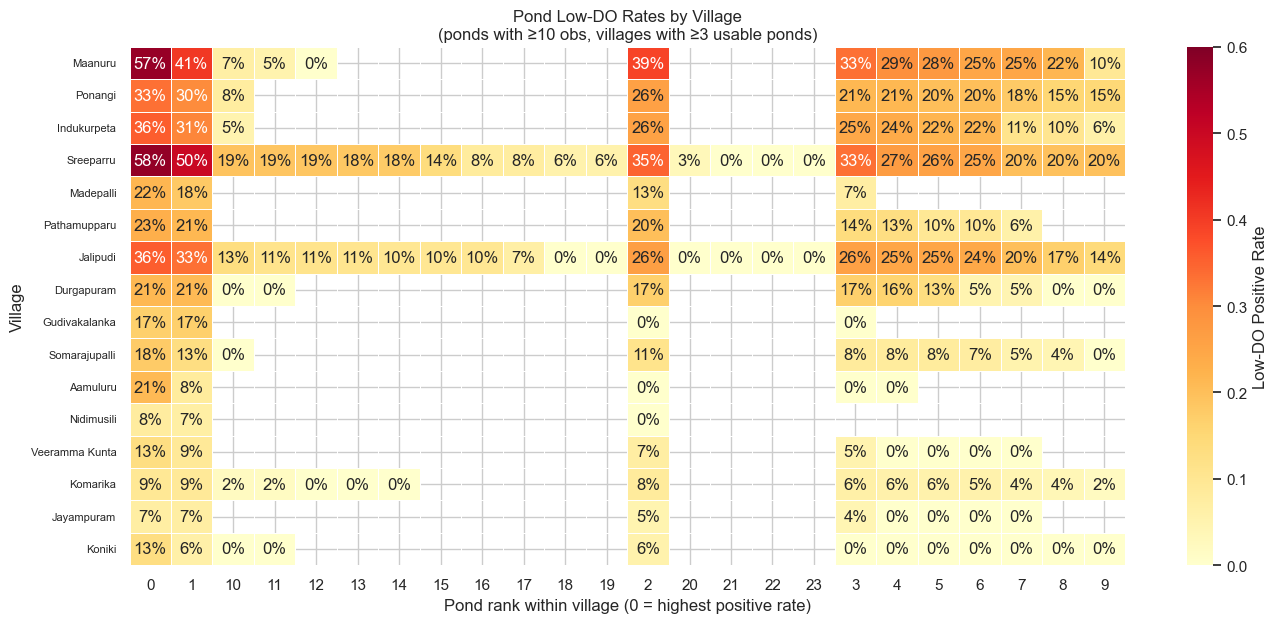

In [9]:
# ── Build a wide matrix: village × pond, value = positive_rate ─────────────────
usable_ponds = pond_summary[pond_summary['n_obs'] >= MIN_OBS_POND].copy()

# For the heatmap, show villages with ≥3 usable ponds
villages_for_heat = wv[wv['usable_ponds'] >= 3]['village'].tolist()
heat_data = usable_ponds[usable_ponds['village'].isin(villages_for_heat)].copy()
heat_data['short_pond'] = heat_data['pond_id'].str[-6:]

# Sort ponds within each village by positive rate for visual clarity
heat_data = heat_data.sort_values(['village', 'positive_rate'], ascending=[True, False])

# Create a sequential pond label within village
heat_data['pond_label'] = heat_data.groupby('village').cumcount().astype(str)

heat_pivot = heat_data.pivot(index='village', columns='pond_label', values='positive_rate')
# Order villages by their mean positive rate
village_order = heat_data.groupby('village')['positive_rate'].mean().sort_values(ascending=False).index
heat_pivot = heat_pivot.reindex(village_order)

fig, ax = plt.subplots(figsize=(max(14, heat_pivot.shape[1] * 0.5),
                                 max(6, heat_pivot.shape[0] * 0.4)))
sns.heatmap(heat_pivot, cmap='YlOrRd', annot=True, fmt='.0%',
            linewidths=0.5, linecolor='white', ax=ax, vmin=0, vmax=0.6,
            cbar_kws={'label': 'Low-DO Positive Rate'})
ax.set_xlabel('Pond rank within village (0 = highest positive rate)')
ax.set_ylabel('Village')
ax.set_title(f'Pond Low-DO Rates by Village\n(ponds with ≥{MIN_OBS_POND} obs, '
             f'villages with ≥3 usable ponds)')
ax.tick_params(axis='y', labelsize=8)
plt.tight_layout()
plt.show()

## 3e — Test-Set Sampling Implications

Minimum viable test-set requirements for binary classification: typically ≥50 positive and ≥50 negative samples per stratum to get stable precision/recall estimates. Below we evaluate both stratification strategies.

In [10]:
MIN_POS_TEST = 10   # minimum positive samples per stratum for test set
MIN_NEG_TEST = 10   # minimum negative samples per stratum for test set

# ========================================================================
# BETWEEN-VILLAGE ASSESSMENT
# ========================================================================
print("=" * 70)
print("BETWEEN-VILLAGE: Can we predict which villages will be relatively worse?")
print("=" * 70)

# Classify villages as "frequently low-DO" vs "rarely low-DO"
overall_rate = df['low_do'].mean()
village_summary['village_class'] = np.where(
    village_summary['positive_rate'] > overall_rate, 'High-risk village', 'Low-risk village')

print(f"\nOverall low-DO rate: {overall_rate*100:.1f}%")
print(f"Villages above overall rate (high-risk): "
      f"{(village_summary['village_class'] == 'High-risk village').sum()}")
print(f"Villages below overall rate (low-risk): "
      f"{(village_summary['village_class'] == 'Low-risk village').sum()}")

# Check if each village has enough pos & neg for stratified sampling
village_summary['sufficient_pos'] = village_summary['n_positive'] >= MIN_POS_TEST
village_summary['sufficient_neg'] = village_summary['n_negative'] >= MIN_NEG_TEST
village_summary['sufficient_both'] = village_summary['sufficient_pos'] & village_summary['sufficient_neg']

print(f"\nVillages with ≥{MIN_POS_TEST} positive AND ≥{MIN_NEG_TEST} negative obs: "
      f"{village_summary['sufficient_both'].sum()} / {len(village_summary)}")
print(f"  → These can contribute to a village-stratified test set.\n")

# Pooled numbers
pooled_pos = village_summary.loc[village_summary['sufficient_both'], 'n_positive'].sum()
pooled_neg = village_summary.loc[village_summary['sufficient_both'], 'n_negative'].sum()
print(f"Pooled usable observations: {pooled_pos + pooled_neg:,} "
      f"(pos={pooled_pos:,}, neg={pooled_neg:,})")
print(f"If 20% held out for test: ~{int((pooled_pos+pooled_neg)*0.2):,} test obs "
      f"(~{int(pooled_pos*0.2):,} positive)")

# ========================================================================
# WITHIN-VILLAGE ASSESSMENT
# ========================================================================
print("\n" + "=" * 70)
print("WITHIN-VILLAGE: Can we predict which ponds within a village are worse?")
print("=" * 70)

feasible_villages = []
for _, row in wv.iterrows():
    v = row['village']
    v_ponds = pond_summary[(pond_summary['village'] == v) &
                           (pond_summary['n_obs'] >= MIN_OBS_POND)]
    if len(v_ponds) < 3:
        continue
    # Need spread in positive rates: at least 1 pond ≥ village median rate and 1 below
    v_rate = v_ponds['positive_rate']
    has_variation = v_rate.std() > 0.02  # minimal variation
    pos_total = v_ponds['n_positive'].sum()
    neg_total = v_ponds['n_negative'].sum()
    feasible_villages.append({
        'village': v,
        'usable_ponds': len(v_ponds),
        'total_obs': v_ponds['n_obs'].sum(),
        'total_pos': pos_total,
        'total_neg': neg_total,
        'rate_std': v_rate.std(),
        'rate_range': v_rate.max() - v_rate.min(),
        'has_variation': has_variation,
        'min_pond_pos': v_ponds['n_positive'].min(),
        'feasible': has_variation and pos_total >= MIN_POS_TEST and neg_total >= MIN_NEG_TEST,
    })

fv = pd.DataFrame(feasible_villages).sort_values('total_obs', ascending=False)
print(f"\nVillages with ≥3 usable ponds: {len(fv)}")
print(f"  with meaningful rate variation (std > 2%): {fv['has_variation'].sum()}")
print(f"  FEASIBLE for within-village modelling: {fv['feasible'].sum()}\n")
print(fv.to_string(index=False, float_format='%.2f'))

# ========================================================================
# CONCLUSION
# ========================================================================
print("\n" + "=" * 70)
print("SUMMARY — DATA SUFFICIENCY")
print("=" * 70)
n_between = village_summary['sufficient_both'].sum()
n_within  = fv['feasible'].sum() if len(fv) else 0
print(f"""
1. BETWEEN-VILLAGE (which villages are worse):
   → {n_between} villages have ≥{MIN_POS_TEST} positive AND ≥{MIN_NEG_TEST} negative obs.
   → Pooled: {pooled_pos + pooled_neg:,} obs ({pooled_pos:,} pos, {pooled_neg:,} neg).
   → {'SUFFICIENT' if n_between >= 6 else 'MARGINAL'} for train/test split.
   → Recommended: {'stratified village-level split' if n_between >= 10 else 'leave-one-village-out CV'}.

2. WITHIN-VILLAGE (which ponds within a village are worse):
   → {n_within} villages are feasible for within-village prediction.
   → {'SUFFICIENT' if n_within >= 5 else 'MARGINAL' if n_within >= 3 else 'INSUFFICIENT'} for generalisation.
   → Recommended: {'village-stratified K-fold' if n_within >= 5 else 'per-village models with pooled priors'}.

3. SAMPLING STRATEGY for test set:
   → Between-village: hold out {'2–3' if n_between < 12 else '4–5'} entire villages (all ponds, all dates).
   → Within-village: within each feasible village, hold out {'20%' if n_within >= 5 else '1 pond'} of ponds.
   → Both strategies should be temporal: use most recent observations in test set.
""")

BETWEEN-VILLAGE: Can we predict which villages will be relatively worse?

Overall low-DO rate: 13.6%
Villages above overall rate (high-risk): 8
Villages below overall rate (low-risk): 14

Villages with ≥10 positive AND ≥10 negative obs: 10 / 22
  → These can contribute to a village-stratified test set.

Pooled usable observations: 4,043 (pos=639, neg=3,404)
If 20% held out for test: ~808 test obs (~127 positive)

WITHIN-VILLAGE: Can we predict which ponds within a village are worse?

Villages with ≥3 usable ponds: 16
  with meaningful rate variation (std > 2%): 16
  FEASIBLE for within-village modelling: 10

       village  usable_ponds  total_obs  total_pos  total_neg  rate_std  rate_range  has_variation  min_pond_pos  feasible
     Sreeparru            24        793        166        627      0.15        0.58           True             0      True
      Komarika            15        667         29        638      0.03        0.09           True             0      True
      Jalipudi 

## 3f — Temporal Distribution of Low-DO Events

For the test set to be representative, low-DO events shouldn't be clustered in one narrow time window. Below we check the temporal spread.

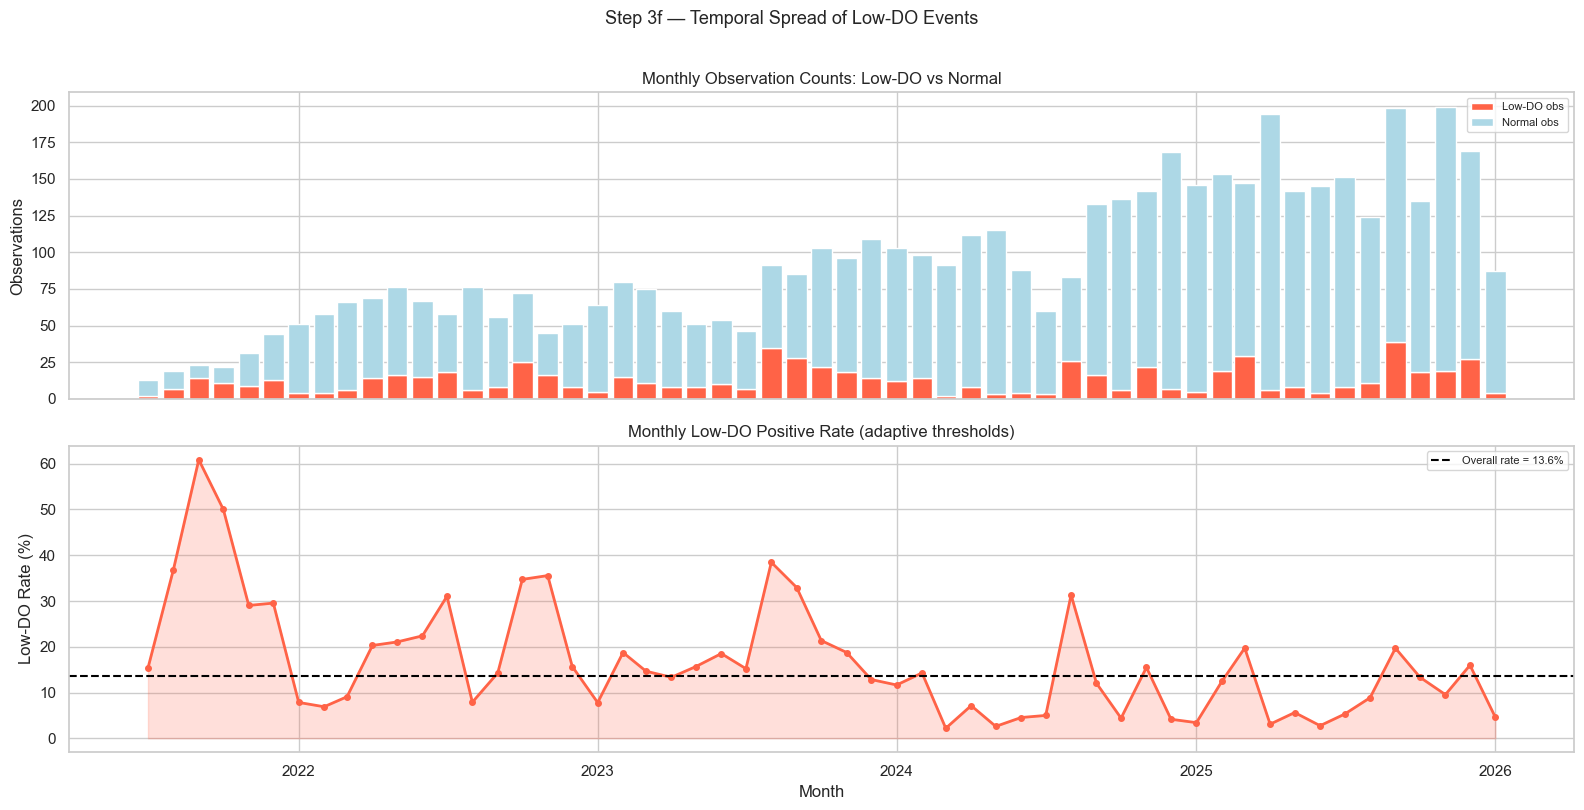

Months with ≥1 low-DO event, per village:
village
Sreeparru          37
Ponangi            33
Maanuru            32
Indukurpeta        31
Jalipudi           21
Komarika           20
Durgapuram         17
Somarajupalli      14
Madepalli          10
Pathamupparu        7
Mudivarthipalem     5
Veeramma Kunta      5
Gudivakalanka       5
Nidimusili          4
Koniki              4
Aamuluru            4
Jayampuram          3
Ankamma Satram      2
Mupparu             2
Chataparru          2


In [11]:
df['month'] = df['date'].dt.to_period('M')

monthly_events = df.groupby('month').agg(
    total_obs=('low_do', 'count'),
    low_do_count=('low_do', 'sum'),
).reset_index()
monthly_events['low_do_rate'] = monthly_events['low_do_count'] / monthly_events['total_obs']
monthly_events['month_dt'] = monthly_events['month'].dt.to_timestamp()

fig, axes = plt.subplots(2, 1, figsize=(16, 8), sharex=True)

ax = axes[0]
ax.bar(monthly_events['month_dt'], monthly_events['low_do_count'], width=25, color='tomato',
       label='Low-DO obs')
ax.bar(monthly_events['month_dt'],
       monthly_events['total_obs'] - monthly_events['low_do_count'],
       bottom=monthly_events['low_do_count'], width=25, color='lightblue', label='Normal obs')
ax.set_ylabel('Observations')
ax.set_title('Monthly Observation Counts: Low-DO vs Normal')
ax.legend(fontsize=8)

ax = axes[1]
ax.plot(monthly_events['month_dt'], monthly_events['low_do_rate'] * 100,
        color='tomato', linewidth=2, marker='o', markersize=4)
ax.fill_between(monthly_events['month_dt'], monthly_events['low_do_rate'] * 100,
                alpha=0.2, color='tomato')
ax.axhline(overall_rate * 100, color='black', linestyle='--',
           label=f'Overall rate = {overall_rate*100:.1f}%')
ax.set_ylabel('Low-DO Rate (%)')
ax.set_xlabel('Month')
ax.set_title('Monthly Low-DO Positive Rate (adaptive thresholds)')
ax.legend(fontsize=8)

plt.suptitle('Step 3f — Temporal Spread of Low-DO Events', fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

# Per village-month: do low-DO events span enough months?
village_month = df[df['low_do'] == 1].groupby('village')['month'].nunique().rename('months_with_low_do')
print("Months with ≥1 low-DO event, per village:")
print(village_month.sort_values(ascending=False).to_string())